# **Multi-Class Sentiment Analysis with BERT**

This notebook shows how to perform multi-class sentiment classification by fine-tuning a **BERT** model on the Huggingface "Emotion" dataset. The code is freely adapted from "Natural Language Processing with Transformers" (O'Reilly ed.)
The following steps will be performed:

- Install required libraries and dependencies.
- Explore and visualize the dataset.
- Preprocess the data and extract embeddings.
- Fine-tune a BERT model with hyperparameter optimization using Optuna.
- Evaluate the final model on a test set.
- Train a multi-class logistic regression classifier as a baseline model to compare results.

---

## **1. Install Required Libraries**

In [ ]:
!pip install datasets transformers optuna umap-learn huggingface_hub accelerate optuna-integration[pytorch_lightning] bertviz -U

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.3/506.3 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.5/157.5 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.3/139.3 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.5/828.5 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 74.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983

## **2. Import Libraries**

In [ ]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset, DatasetDict
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from umap import UMAP
import optuna
from optuna.trial import TrialState
from optuna import TrialPruned
from bertviz import head_view, model_view

## **3. Set Up Device (CPU/GPU)**

In [ ]:
# Set CPU or GPU device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## **4. Load and Split the Dataset**

In [ ]:
# Load the dataset: Huggingface Emtions Dataset: https://huggingface.co/datasets/dair-ai/emotion
emotion_dataset = load_dataset("emotion")
# Shuffle the training dataset to avoid possible bias from any inherent order
# The seed ensures reproducibility of the experiment.
emotion_dataset['train'] = emotion_dataset['train'].shuffle(seed=42)

# Print the sizes of each split
print(f"Number of examples in the training set: {len(emotion_dataset['train'])}")
print(f"Number of examples in the validation set: {len(emotion_dataset['validation'])}")
print(f"Number of examples in the test set: {len(emotion_dataset['test'])}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Number of examples in the training set: 16000
Number of examples in the validation set: 2000
Number of examples in the test set: 2000


## **5. Explore the Dataset**

### **5.1. Map Label IDs to Strings**

In [ ]:
# Function to map label integers to strings
def get_label_name(label_id):
    return emotion_dataset["train"].features["label"].int2str(label_id)   # Converts numeric IDs of labels into corresponding strings ("joy", "sadness" etc.)

### **5.2. Convert Dataset to DataFrame for Exploration**

In [ ]:
# Convert the training dataset to a pandas DataFrame
df_train = emotion_dataset['train'].to_pandas()
df_train["label_name"] = df_train["label"].apply(get_label_name)
df_train.head()

,text,label,label_name
0,while cycling in the country,4,fear
1,i had pocket qq and was feeling pretty confide...,1,joy
2,i am in no way complaining or whining or feeli...,0,sadness
3,i feel a bit stressed because it feels like im...,3,anger
4,i tell the people closest to me things that i ...,5,surprise


### **5.3. Visualize Class Distribution**

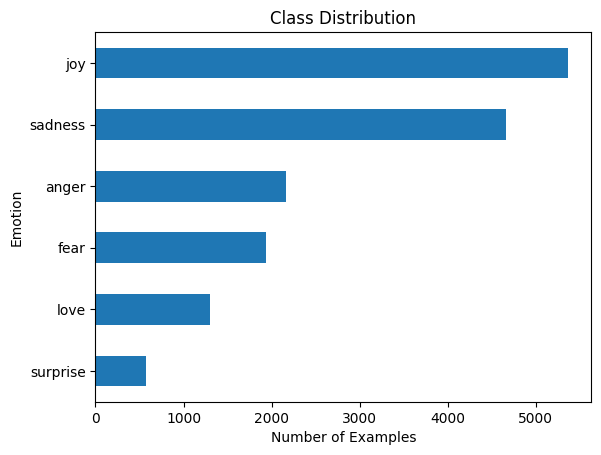

In [ ]:
# Visualize class distribution
df_train["label_name"].value_counts(ascending=True).plot.barh()
plt.title("Class Distribution")
plt.xlabel("Number of Examples")
plt.ylabel("Emotion")
plt.show()

## **6. Preprocessing and Tokenization**

### **6.1. Choose the BERT Model and Initialize Tokenizer**

In [ ]:
# Initialize tokenizer and model

model_name = "bert-base-uncased"
# model_name = "bert-large-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

print(f"Tokenizer size (vocab size): {tokenizer.vocab_size}")             # about 30000 for BERT
print(f"Max sequence length (max tokens): {tokenizer.model_max_length}")  # 512 for BERT

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer size (vocab size): 30522
Max sequence length (max tokens): 512


### **6.2. Define Tokenization Function**

In [ ]:
# Tokenization function
def preprocess_data(batch):
    return tokenizer(batch["text"], padding=True, truncation=True)  # Tokenize the input text, pad shorter sequences, and truncate longer ones to fit the model's input size.

### **6.3. Apply Tokenization to Datasets**

In [ ]:
# Apply tokenization to the Dataset splits (train, validation, test)
tokenized_datasets = {}
for dataset in ['train', 'validation', 'test']:
    tokenized_datasets[dataset] = emotion_dataset[dataset].map(preprocess_data, batched=True)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

### **6.4. Print Training Tokenized Samples**

In [ ]:
tokenized_datasets["train"].set_format(type="pandas")

# View First 5 Tokenized Train samples
tokenized_datasets["train"][:5]

,text,label,input_ids,token_type_ids,attention_mask
0,while cycling in the country,4,"[101, 2096, 9670, 1999, 1996, 2406, 102, 0, 0,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,i had pocket qq and was feeling pretty confide...,1,"[101, 1045, 2018, 4979, 1053, 4160, 1998, 2001...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, ..."
2,i am in no way complaining or whining or feeli...,0,"[101, 1045, 2572, 1999, 2053, 2126, 17949, 203...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3,i feel a bit stressed because it feels like im...,3,"[101, 1045, 2514, 1037, 2978, 13233, 2138, 200...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,i tell the people closest to me things that i ...,5,"[101, 1045, 2425, 1996, 2111, 7541, 2000, 2033...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."


### **6.5. Display Vocabulary Tokens**

In [ ]:
# Take the third train sample text
sample_text = tokenized_datasets["train"]["text"][2]

# Take input_ids of third train sample
sample_input_ids = tokenized_datasets["train"]["input_ids"][2]

# Convert input_ids into vocabulary tokens
tokens = tokenizer.convert_ids_to_tokens(sample_input_ids)

# Stampa il testo originale e i token corrispondenti
print("Original Text:", sample_text)
print("Tokenized Text:", tokens)

Original Text: i am in no way complaining or whining or feeling ungrateful
Tokenized Text: ['[CLS]', 'i', 'am', 'in', 'no', 'way', 'complaining', 'or', 'w', '##hini', '##ng', 'or', 'feeling', 'un', '##grate', '##ful', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


## **7. Extract Embeddings with BERT**

### **7.1. Load Pre-trained BERT Model**

In [ ]:
# Load pre-trained BERT model without classification head
base_model = AutoModel.from_pretrained(model_name).to(device)   # Move the model to the identified device (CPU or GPU) for processing
print(f"Input embedding size: {base_model.config.hidden_size}")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Input embedding size: 768


### **7.2. Define Function to Extract [CLS] Token Hidden States**

In [ ]:
# Function to extract [CLS] token contextual hidden states
def extract_cls_embeddings(batch):
    inputs = {k: v.to(device) for k, v in batch.items() if k in tokenizer.model_input_names}  # select BERT supported keys: "input_ids", "attention_mask", ...
    with torch.no_grad():   # Disable gradient calculation to save memory and computation when extracting hidden states
        outputs = base_model(**inputs)  # Get BERT's hidden states (without any task-specific head)
    return {"cls_embedding": outputs.last_hidden_state[:, 0].cpu().numpy()}   # Extracts the hidden state of the first ([:, 0]) token (i.e.: [CLS]) from the last layer for each sequence in the batch.

### **7.3. Set Format for PyTorch Tensors**

In [ ]:
# Set format for PyTorch tensors: convert DatasetDict columns "input_ids", "attention_mask" and "label" into torch tensors
for dataset in ['train', 'validation', 'test']:
    tokenized_datasets[dataset].set_format("torch", columns=["input_ids", "attention_mask", "label"])

### **7.4. Extract [CLS] Contextual Hidden States for All Dataset Splits (Train, Validation, Test)**

In [ ]:
# Extract [CLS] contextual hidden states from the last layer for all data
cls_hs_datasets = {}
for dataset_split in ["train", "validation", "test"]:
    cls_hs_datasets[dataset_split] = tokenized_datasets[dataset_split].map(extract_cls_embeddings, batched=True)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

## **8. Visualize Embeddings with UMAP**

In [ ]:
# Split dataset into Train, Validation and Test
X_train = np.array(cls_hs_datasets["train"]["cls_embedding"])
y_train = np.array(cls_hs_datasets["train"]["label"])
X_val = np.array(cls_hs_datasets["validation"]["cls_embedding"])
y_val = np.array(cls_hs_datasets["validation"]["label"])
X_test = np.array(cls_hs_datasets["test"]["cls_embedding"])
y_test = np.array(cls_hs_datasets["test"]["label"])

### **8.1. Reduce Dimensionality with UMAP**

In [ ]:
# Reduce dimensionality with UMAP
# Scale features to [0,1] range
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_train)
umap_mapper = UMAP(n_components=2, metric="cosine").fit(X_scaled)

### **8.2. Create DataFrame for Embeddings**

In [ ]:
# Create a DataFrame for embeddings
df_embeddings = pd.DataFrame(umap_mapper.embedding_, columns=["X", "Y"])
df_embeddings["label"] = y_train
df_embeddings["label_name"] = df_embeddings["label"].apply(get_label_name)
print(f"The total number of embeddings (one per tweet) is: {len(df_embeddings)}")
df_embeddings.head()

The total number of embeddings (one per tweet) is: 16000


,X,Y,label,label_name
0,-7.631466,8.381010,4,fear
1,-6.443297,10.477834,1,joy
2,-4.419431,7.076953,0,sadness
3,8.124708,8.619599,3,anger
4,9.668807,10.556580,5,surprise


### **8.3. Plot Embeddings**

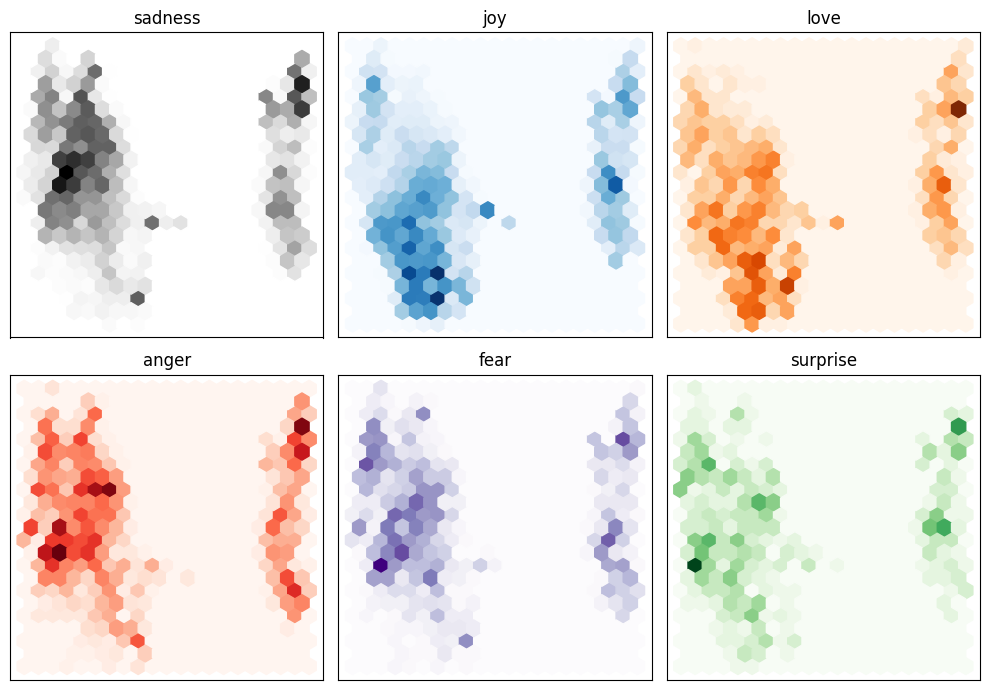

In [ ]:
# Plot embeddings
fig, axes = plt.subplots(2, 3, figsize=(10, 7))
axes = axes.flatten()
colormaps = ["Greys", "Blues", "Oranges", "Reds", "Purples", "Greens"]
emotion_labels = emotion_dataset["train"].features["label"].names

for idx, (label, cmap) in enumerate(zip(emotion_labels, colormaps)):
    subset = df_embeddings[df_embeddings["label"] == idx]
    axes[idx].hexbin(subset["X"], subset["Y"], gridsize=20, cmap=cmap)
    axes[idx].set_title(label)
    axes[idx].set_xticks([])
    axes[idx].set_yticks([])

plt.tight_layout()
plt.show()

## **9. Fine-tune BERT with Hyperparameter Optimization**

### **9.1. Define Model Initialization and Metrics**

In [ ]:
# Function to initialize the model
def model_init():
    num_classes = emotion_dataset["train"].features["label"].num_classes  # retrieve number of classes from the emotion dataset
    return AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_classes).to(device)  # AutoModelForSequenceClassification automatically adds a classification layer on top of BERT with 'num_labels' outputs.

# Function to compute metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred  # Logits are the raw output values from the model's last layer, typically of shape (batch_size, num_classes).
    predictions = np.argmax(logits, axis=-1)  # Selects the index of the highest logit for each example, which corresponds to the predicted class.
    acc = accuracy_score(labels, predictions) # Scikit-learn accuracy_score function
    f1 = f1_score(labels, predictions, average="weighted")  # Scikit-learn f1_score function
    return {"accuracy": acc, "f1": f1}

### **9.2. Define Objective Function for Optuna**

In [ ]:
# Objective function for Optuna
def objective(trial):
    # Suggest hyperparameters
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True)
    num_train_epochs = trial.suggest_int("num_train_epochs", 2, 8)
    per_device_batch_size = trial.suggest_categorical("per_device_batch_size", [16, 32, 64])

    # Define training arguments
    training_args = TrainingArguments(
        output_dir="optuna_outputs",
        eval_strategy="epoch",    # Evaluate the model at the end of each epoch
        learning_rate=learning_rate,
        per_device_train_batch_size=per_device_batch_size,
        per_device_eval_batch_size=per_device_batch_size,
        num_train_epochs=num_train_epochs,
        weight_decay=0.01,              # Apply weight decay (regularization) to prevent overfitting
        logging_strategy="epoch",       # Log metrics once per epoch.
        save_strategy="no",             # Do not Save the model at the end of each epoch
        disable_tqdm=False,
        push_to_hub=False,              # report_to="none"
    )

    # Initialize Trainer
    trainer = Trainer(
        model_init=model_init,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
    )

    # Train model
    trainer.train()

    # Evaluate model
    eval_result = trainer.evaluate()

    # Report F1 score to Optuna
    trial.report(eval_result["eval_f1"], step=trainer.state.global_step)  # Keeps track of the evaluation metric at each step (batch)

    # Check if the current trial should be pruned before its completion, based on poor performance (as reported by trial.report)
    if trial.should_prune():
        raise optuna.exceptions.TrialPruned()

    return eval_result["eval_f1"]     # Metric to be maximized by Optuna (F1 socre is a good choice when the dataste is not balanced)

### **9.3. Run Hyperparameter Optimization**

In [ ]:
# Set the number of trials for Optuna
trials_num = 10

# Create Optuna study and optimize
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=trials_num)

[I 2025-10-15 12:45:19,033] A new study created in memory with name: no-name-d7818622-95c1-4756-ad11-fcfbfd025e5a
/tmp/ipython-input-2471621219.py:24: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence 

<IPython.core.display.Javascript object>

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: gianni-pantaleo (gianni-pantaleo-university-of-florence) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.395000,0.225519,0.928000,0.926959
2,0.153400,0.145283,0.938000,0.938019
3,0.114400,0.188159,0.932500,0.932991
4,0.087800,0.256291,0.934500,0.934509
5,0.056300,0.278731,0.935500,0.935850
6,0.029300,0.326125,0.939500,0.939518
7,0.017600,0.343744,0.938500,0.938480


[I 2025-10-15 13:14:20,180] Trial 0 finished with value: 0.9384801123428741 and parameters: {'learning_rate': 4.574920374231813e-05, 'num_train_epochs': 7, 'per_device_batch_size': 16}. Best is trial 0 with value: 0.9384801123428741.
/tmp/ipython-input-2471621219.py:24: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and

...

[I 2025-10-15 15:34:51,732] Trial 7 finished with value: 0.9407633542027638 and parameters: {'learning_rate': 3.9921870463150825e-05, 'num_train_epochs': 5, 'per_device_batch_size': 16}. Best is trial 2 with value: 0.9421239784304594.
/tmp/ipython-input-2471621219.py:24: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions an

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.386400,0.203229,0.928500,0.926846
2,0.145300,0.161844,0.938000,0.937261
3,0.107300,0.152909,0.943000,0.943594
4,0.079300,0.211656,0.940000,0.940027
5,0.040300,0.259132,0.944500,0.944476


[I 2025-10-15 15:55:24,171] Trial 8 finished with value: 0.9444755907850985 and parameters: {'learning_rate': 4.865678273352667e-05, 'num_train_epochs': 5, 'per_device_batch_size': 16}. Best is trial 8 with value: 0.9444755907850985.
/tmp/ipython-input-2471621219.py:24: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.410000,0.157710,0.935500,0.935763
2,0.144900,0.150744,0.939000,0.938690
3,0.098400,0.161994,0.938000,0.938420
4,0.063800,0.211018,0.938500,0.938427


[I 2025-10-15 16:11:53,567] Trial 9 finished with value: 0.9384265477231308 and parameters: {'learning_rate': 4.132797690533785e-05, 'num_train_epochs': 4, 'per_device_batch_size': 16}. Best is trial 8 with value: 0.9444755907850985.


### **9.4. Find the Best Trial and Display Best Hyperparameters**

In [ ]:
# Find the best trial after Optuna optimization
best_trial = study.best_trial
print(f"Best trial number: {best_trial.number}")

# Best hyperparameters
print("Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

Best trial number: 8
Best Hyperparameters:
  learning_rate: 4.865678273352667e-05
  num_train_epochs: 5
  per_device_batch_size: 16


## **10. Train Model with Best Hyperparameters and Perform Evaluation**

In [ ]:
# Re-train the final model with the best hyperparameters found by Optuna
final_model = model_init()

best_training_args = TrainingArguments(
    output_dir="best_model_output",
    eval_strategy="epoch",  # Evaluate at the end of each epoch
    learning_rate=study.best_params["learning_rate"],  # Use the best learning rate from Optuna
    per_device_train_batch_size=study.best_params["per_device_batch_size"],  # Best batch size from Optuna
    per_device_eval_batch_size=study.best_params["per_device_batch_size"],
    num_train_epochs=study.best_params["num_train_epochs"],  # Best number of epochs from Optuna
    weight_decay=0.01,
    logging_strategy="epoch",
    save_strategy="no",
    disable_tqdm=False,
    push_to_hub=False,  # report_to="none"
)

final_trainer = Trainer(
    model=final_model,
    args=best_training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],  # Use validation for evaluation during training
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,  # The metric function defined earlier
)

# Train the final model
final_trainer.train()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-553190773.py:32: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  final_trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.408400,0.189706,0.929000,0.927306
2,0.144900,0.148392,0.937500,0.937647
3,0.108600,0.177982,0.934000,0.934417
4,0.076000,0.241825,0.934500,0.934441
5,0.039100,0.326628,0.932000,0.931658


TrainOutput(global_step=5000, training_loss=0.15540429000854492, metrics={'train_runtime': 1210.3, 'train_samples_per_second': 66.099, 'train_steps_per_second': 4.131, 'total_flos': 3429734667906240.0, 'train_loss': 0.15540429000854492, 'epoch': 5.0})

## **11. Evaluate Final Model on Test Set**

In [ ]:
# Evaluate on test set
test_results = final_trainer.predict(tokenized_datasets["test"])
test_accuracy = accuracy_score(test_results.label_ids, np.argmax(test_results.predictions, axis=-1))
test_f1 = f1_score(test_results.label_ids, np.argmax(test_results.predictions, axis=-1), average="weighted")
print(f"Test Set Performance - Accuracy: {test_accuracy:.4f}, F1 Score: {test_f1:.4f}")

Test Set Performance - Accuracy: 0.9285, F1 Score: 0.9283


### **11.1. Confusion Matrix on Test Set**

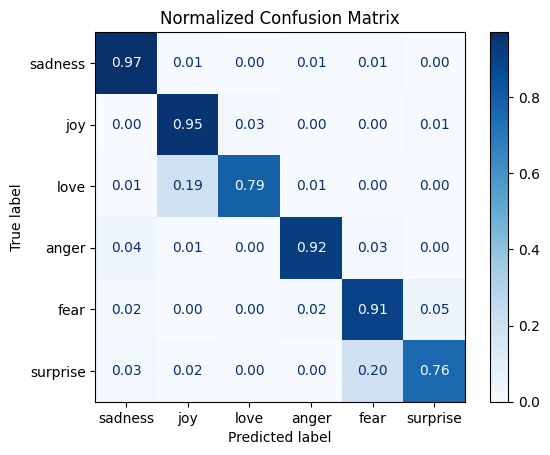

In [ ]:
def plot_confusion(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, normalize="true")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues", values_format=".2f")
    plt.title("Normalized Confusion Matrix")
    plt.show()

# Plot confusion matrix for the final model on test set
y_pred_test = np.argmax(test_results.predictions, axis=1)
plot_confusion(test_results.label_ids, y_pred_test, emotion_labels)

## **12. Display Test Samples and Visualize Attention with BertViz**

### **12.1. Display Test Sample: Predicted VS Actual labels with Loss**

In [ ]:
tokenized_datasets["test"].set_format("pandas")
df_test = tokenized_datasets["test"].to_pandas()

df_test["label_name"] = df_test["label"].apply(get_label_name)
df_test["predicted_label_name"] = np.argmax(test_results.predictions, axis=-1)
df_test[["text", "label_name", "predicted_label_name"]].head()

,text,label_name,predicted_label_name
0,im feeling rather rotten so im not very ambiti...,sadness,0
1,im updating my blog because i feel shitty,sadness,0
2,i never make her separate from me because i do...,sadness,0
3,i left with my bouquet of red and yellow tulip...,joy,1
4,i was feeling a little vain when i did this one,sadness,0


### **12.2. Visualize Attention with BertViz**

In [ ]:
# Select a single tweet
df_test = df_test.iloc[0]
text = df_test["text"]
print(f"Test set Tweet sample: {text}")

# Tokenize the selected tweet (using the previously defined tokenizer)
inputs = tokenizer(text, return_tensors="pt").to(device)

#Run the model on the input to get attention (using the trained model)
outputs = final_trainer.model(**inputs, output_attentions=True)
attention = outputs.attentions

# Visualize the attention with BertViz (Head View)
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"].squeeze().tolist())
head_view(attention, tokens)

BertSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


Test set Tweet sample: im feeling rather rotten so im not very ambitious right now


<IPython.core.display.Javascript object>

## **13. Evaluation Comparison with a Baseline Model**

### **13.1. Define and Train Classifier (Scikit-Learn Multi-Class Logistic Regression Classifier)**

In [ ]:
# Train logistic regression classifier (sklearn can handles multi-class classification in LogisticRegression).
# logistic_clf = LogisticRegression(max_iter=3000)
logistic_clf = LogisticRegression(multi_class='multinomial', solver='newton-cg', max_iter=3000)   # max_iter=3000 to ensure convergence
logistic_clf.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=3000, multi_class='multinomial', solver='newton-cg')

### **13.2. Evaluate Classifier (Baseline Model)**

In [ ]:
# Evaluate baseline model on test set
test_score = logistic_clf.score(X_test, y_test)
print(f"Test Accuracy (Baseline Model): {test_score:.4f}")

Test Accuracy (Baseline Model): 0.6065


### **13.3. Baseline Confusion Matrix on Test Set**

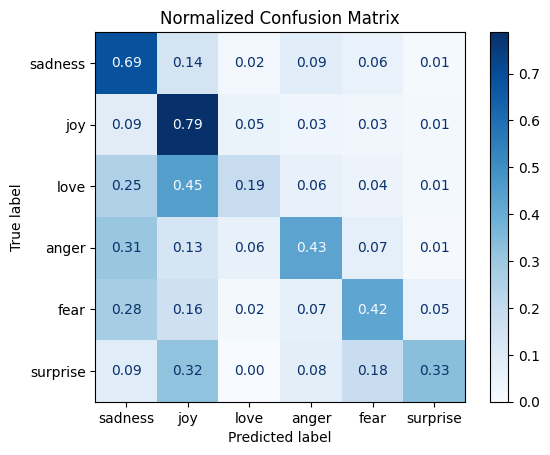

In [ ]:
# Compute confusion matrix for baseline model on test set
y_pred_lr = logistic_clf.predict(X_test)

def plot_confusion(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, normalize="true")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues", values_format=".2f")
    plt.title("Normalized Confusion Matrix")
    plt.show()

plot_confusion(y_test, y_pred_lr, emotion_labels)